<a href="https://colab.research.google.com/github/SinCosTanTya/Lifestyle-and-Health/blob/main/Lifestyle_and_Health_Research_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Research question: Does a person’s sex have a statistically significant influence on the relationship between BMI and systolic blood pressure?

> Add blockquote



In [82]:
import csv
import pandas as pd
import numpy as np
!pip install matplotlib
import matplotlib.pyplot as plt
!pip install scikit-learn
import scipy.stats as stats
from sklearn import datasets, model_selection
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
import matplotlib.patches as Patch
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [83]:
#Importing the dataframe
url="https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/NHANES%202017-2018%20Data/nhanes_2017_2018_healthy_habits_cleaned.csv"
health_df=pd.read_csv(url)
health_df.head()

,age,gender,sleep_hours_weekday,bmi,systolic_bp,diastolic_bp,minutes_sedentary_daily,vigorous_recreational_activity,moderate_recreational_activity,walk_or_bicycle,general_health,feel_hopeless,feel_depressed,feel_anxious,diet_quality,fast_food_meals_per_week,daily_sugar_grams,daily_fiber_grams,daily_fat_grams,daily_protein_grams
0,2.0,Female,NaN,17.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,2.0,Male,NaN,15.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.97,5.9,43.24,51.58
2,66.0,Female,8.0,31.7,NaN,NaN,300.0,No,Yes,No,Good,Not at all,Several days,Several days,Good,0.0,91.55,8.4,56.98,20.01
3,18.0,Male,10.5,21.5,112.0,74.0,240.0,No,Yes,Yes,Very good,Not at all,Not at all,Not at all,Very good,3.0,14.73,7.1,137.39,94.19
4,13.0,Male,NaN,18.1,128.0,38.0,NaN,NaN,NaN,NaN,Good,NaN,NaN,NaN,NaN,1.0,84.22,10.9,89.18,59.48


In [84]:
#Gaining general info about my dataframe
health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             8366 non-null   float64
 1   gender                          8366 non-null   object 
 2   sleep_hours_weekday             5783 non-null   float64
 3   bmi                             8005 non-null   float64
 4   systolic_bp                     6302 non-null   float64
 5   diastolic_bp                    6302 non-null   float64
 6   minutes_sedentary_daily         5491 non-null   float64
 7   vigorous_recreational_activity  5533 non-null   object 
 8   moderate_recreational_activity  5533 non-null   object 
 9   walk_or_bicycle                 5533 non-null   object 
 10  general_health                  5964 non-null   object 
 11  feel_hopeless                   5087 non-null   object 
 12  feel_depressed                  51

In [85]:
#Checking for duplicates
value=health_df.duplicated().sum()
print(value)

50


In [86]:
#Drop the 50 duplicates
health_df=health_df.drop_duplicates()
#Check to make sure it worked
health_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8316 entries, 0 to 8365
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             8316 non-null   float64
 1   gender                          8316 non-null   object 
 2   sleep_hours_weekday             5783 non-null   float64
 3   bmi                             7997 non-null   float64
 4   systolic_bp                     6302 non-null   float64
 5   diastolic_bp                    6302 non-null   float64
 6   minutes_sedentary_daily         5491 non-null   float64
 7   vigorous_recreational_activity  5533 non-null   object 
 8   moderate_recreational_activity  5533 non-null   object 
 9   walk_or_bicycle                 5533 non-null   object 
 10  general_health                  5964 non-null   object 
 11  feel_hopeless                   5087 non-null   object 
 12  feel_depressed                  5136 no

In [87]:
#Replace NaN with the string "None"

health_df = health_df.fillna("None")
health_df.head()

,age,gender,sleep_hours_weekday,bmi,systolic_bp,diastolic_bp,minutes_sedentary_daily,vigorous_recreational_activity,moderate_recreational_activity,walk_or_bicycle,general_health,feel_hopeless,feel_depressed,feel_anxious,diet_quality,fast_food_meals_per_week,daily_sugar_grams,daily_fiber_grams,daily_fat_grams,daily_protein_grams
0,2.0,Female,None,17.5,None,None,None,None,None,None,None,None,None,None,None,0.0,None,None,None,None
1,2.0,Male,None,15.7,None,None,None,None,None,None,None,None,None,None,None,None,76.97,5.9,43.24,51.58
2,66.0,Female,8.0,31.7,None,None,300.0,No,Yes,No,Good,Not at all,Several days,Several days,Good,0.0,91.55,8.4,56.98,20.01
3,18.0,Male,10.5,21.5,112.0,74.0,240.0,No,Yes,Yes,Very good,Not at all,Not at all,Not at all,Very good,3.0,14.73,7.1,137.39,94.19
4,13.0,Male,None,18.1,128.0,38.0,None,None,None,None,Good,None,None,None,None,1.0,84.22,10.9,89.18,59.48


In [88]:
#Convert the string "None" back to a proper NaN object

health_df = health_df.replace("None", np.nan)

/tmp/ipykernel_1285/1365726001.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  health_df = health_df.replace("None", np.nan)


In [89]:
#Column name good, data types are good, and data is in a tidy format, but many null values ESPECIALLY in bmi and systolic bp columns
new_health_df = health_df.dropna(axis=0,how='any',subset=['bmi','systolic_bp'])
#Check to make sure it worked
new_health_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6230 entries, 3 to 8365
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             6230 non-null   float64
 1   gender                          6230 non-null   object 
 2   sleep_hours_weekday             5069 non-null   float64
 3   bmi                             6230 non-null   float64
 4   systolic_bp                     6230 non-null   float64
 5   diastolic_bp                    6230 non-null   float64
 6   minutes_sedentary_daily         4803 non-null   float64
 7   vigorous_recreational_activity  4833 non-null   object 
 8   moderate_recreational_activity  4833 non-null   object 
 9   walk_or_bicycle                 4833 non-null   object 
 10  general_health                  5313 non-null   object 
 11  feel_hopeless                   4537 non-null   object 
 12  feel_depressed                  4505 no

In [90]:
#What are the means, medians, and modes of each variable
new_health_df.describe()

,age,sleep_hours_weekday,bmi,systolic_bp,diastolic_bp,minutes_sedentary_daily,fast_food_meals_per_week,daily_sugar_grams,daily_fiber_grams,daily_fat_grams,daily_protein_grams
count,6230.000000,5069.000000,6230.000000,6230.000000,6.230000e+03,4.803000e+03,4840.000000,5696.000000,5686.000000,5694.000000,5693.000000
mean,41.117335,7.626159,27.913740,121.155698,6.780610e+01,3.311170e+02,3.249174,108.331603,16.389043,84.411549,77.715484
std,22.606205,1.650176,7.686538,19.733979,1.633333e+01,1.990431e+02,79.859954,76.804625,10.571941,49.075488,42.559881
min,8.000000,2.000000,13.100000,72.000000,5.397605e-79,5.397605e-79,0.000000,0.710000,0.100000,0.210000,0.050000
25%,19.000000,6.500000,22.600000,106.000000,6.000000e+01,1.800000e+02,1.000000,57.260000,9.100000,51.132500,49.590000
50%,40.500000,7.500000,26.950000,118.000000,7.000000e+01,3.000000e+02,1.000000,92.725000,14.200000,75.830000,69.830000
75%,61.000000,8.500000,32.000000,132.000000,7.600000e+01,4.800000e+02,3.000000,139.365000,21.100000,107.047500,97.350000
max,80.000000,14.000000,84.400000,224.000000,1.240000e+02,1.320000e+03,5555.000000,931.160000,107.800000,567.960000,545.200000


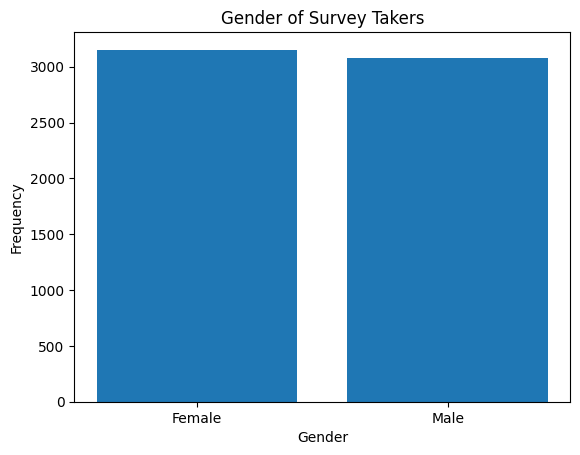

In [91]:
#I think I want to make a bar chart of amount of females that took the surverys and Males
counts=new_health_df['gender'].value_counts()
plt.bar(counts.index,counts.values)
plt.title('Gender of Survey Takers')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

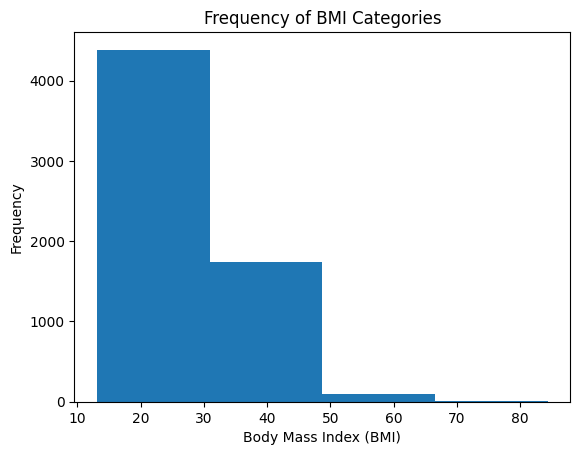

In [92]:
#Visualize data for BMI
plt.hist(new_health_df['bmi'],bins=4)

plt.title('Frequency of BMI Categories')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Frequency')

plt.show()
#question, when putting the BMI into bins, how do I do that

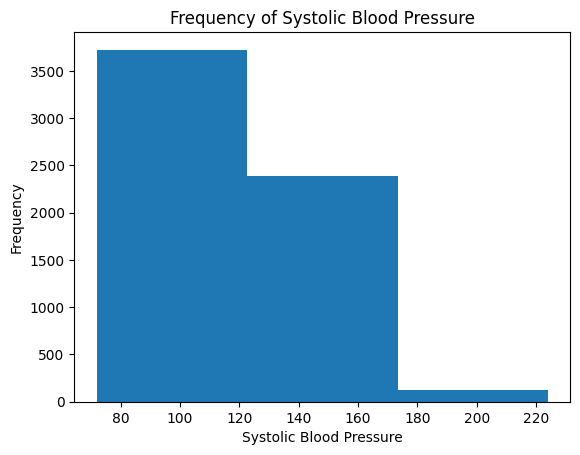

In [93]:
#Visualize data for fast food meals per week
plt.hist(new_health_df['systolic_bp'],bins=3)

plt.title('Frequency of Systolic Blood Pressure')
plt.xlabel('Systolic Blood Pressure')
plt.ylabel('Frequency')

plt.show()

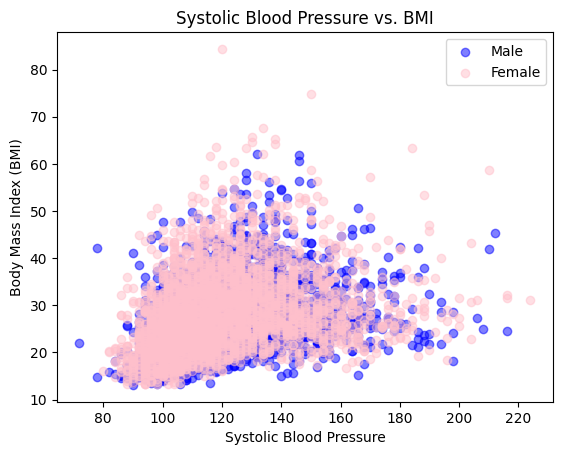

In [94]:
# Linear Regression
#Split data into female and male
female_df=new_health_df[new_health_df['gender']=='Female']
male_df=new_health_df[new_health_df['gender']=='Male']

#Set scatterplot
plt.scatter(male_df['systolic_bp'],male_df['bmi'],c='blue',alpha=0.5,label='Male')
plt.scatter(female_df['systolic_bp'],female_df['bmi'],c='pink',alpha=0.5,label='Female')

plt.title('Systolic Blood Pressure vs. BMI')
plt.xlabel('Systolic Blood Pressure')
plt.ylabel('Body Mass Index (BMI)')

plt.legend()
plt.show()
#Is there a way I can put these side by side?

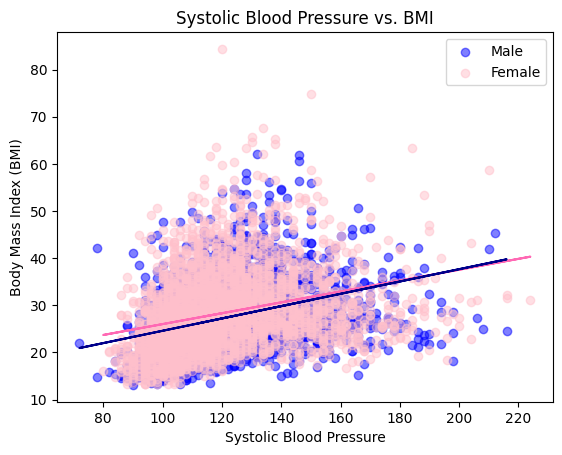

In [95]:
import csv
import pandas as pd
import numpy as np
!pip install matplotlib
import matplotlib.pyplot as plt
!pip install scikit-learn
from sklearn import datasets, model_selection
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression
import matplotlib.patches as Patch
from sklearn.linear_model import LinearRegression

# Linear Regression
#Split data into female and male
female_df=new_health_df[new_health_df['gender']=='Female']
male_df=new_health_df[new_health_df['gender']=='Male']

#Set scatterplot
plt.scatter(male_df['systolic_bp'],male_df['bmi'],c='blue',alpha=0.5,label='Male')
plt.scatter(female_df['systolic_bp'],female_df['bmi'],c='pink',alpha=0.5,label='Female')

# initialize model
female_model=LinearRegression()
female_model.fit(female_df[['systolic_bp']],female_df['bmi'])
female_pred=female_model.predict(female_df[['systolic_bp']])
plt.plot(female_df['systolic_bp'],female_pred,color='hotpink')
male_model=LinearRegression()
male_model.fit(male_df[['systolic_bp']],male_df['bmi'])
male_pred=male_model.predict(male_df[['systolic_bp']])
plt.plot(male_df['systolic_bp'],male_pred,color='darkblue')

#Add labels
plt.title('Systolic Blood Pressure vs. BMI')
plt.xlabel('Systolic Blood Pressure')
plt.ylabel('Body Mass Index (BMI)')

plt.legend()
plt.show()

In [96]:
#Female r2 info
print('mean squared:',mean_squared_error(female_df['bmi'],female_pred))
print('mean absolute:',mean_absolute_error(female_df['bmi'],female_pred))
print('r2 score:',r2_score(female_df['bmi'],female_pred))

mean squared: 61.768831792752316
mean absolute: 6.072545799724915
r2 score: 0.08594681533195547


In [97]:
#Male r2 info
print('mean squared:',mean_squared_error(male_df['bmi'],male_pred))
print('mean absolute:',mean_absolute_error(male_df['bmi'],male_pred))
print('r2 score:',r2_score(male_df['bmi'],male_pred))

mean squared: 44.2350692488197
mean absolute: 5.186409545219177
r2 score: 0.11587576523629228


In [98]:
#Complete the ANOVA
f_statistic, p_value = stats.f_oneway(female_df['bmi'], male_df['bmi'], female_df['systolic_bp'],male_df['systolic_bp'])
print("F-statistic:", f_statistic)
print("p-value:", p_value)

F-statistic: 40393.92646428605
p-value: 0.0


In [99]:
#Complete the Tukey HSD
bmi_tukey=pairwise_tukeyhsd(endog=new_health_df['bmi'],groups=new_health_df['gender'])
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
Female   Male    2.284   0.0 1.3052 3.2627   True
-------------------------------------------------


In [100]:
#Exact Tukey p-values
bmi_tukey.pvalues

array([3.09317064e-05])

In [101]:
systolic_bp_tukey=pairwise_tukeyhsd(endog=new_health_df['systolic_bp'],groups=new_health_df['gender'])
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
Female   Male    2.284   0.0 1.3052 3.2627   True
-------------------------------------------------


In [102]:
#Exact Tukey p-values
systolic_bp_tukey.pvalues

array([4.86446703e-06])